In [1]:
#load model and predictions

from datasets import load_dataset
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

#load data 
dataset = load_dataset("google-research-datasets/go_emotions","simplified")
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])
label_names = dataset['train'].features['labels'].feature.names

#To find single label textts only

train_single = train_df[train_df['labels'].apply(len)==1].copy()
test_single = test_df[test_df['labels'].apply(len)==1].copy()

train_single['label']= train_single['labels'].apply(lambda x: x[0])
test_single['label']= test_single['labels'].apply(lambda x: x[0])

X_train = train_single ['text'].tolist()
Y_train = train_single ['label'].tolist()
X_test = test_single ['text'].tolist()
Y_test = test_single ['label'].tolist()

# Vectorizer and model — using v2 (with stopwords removed)

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter = 1000)
model.fit(X_train_tfidf, Y_train)
Y_pred = model.predict(X_test_tfidf)

print("Setup complete.")


Setup complete.


In [5]:
#classification report

#This gives precision , Recall , F1 for every emotion separately
from sklearn.metrics import classification_report

report = classification_report(
    Y_test,
    Y_pred,
    target_names = label_names,
    output_dict=True,
    zero_division = 0   
)

df = pd.DataFrame(report).transpose()
df_sorted =  df.sort_values(by='f1-score', ascending=True)

print(df_sorted)

#print(report)

                precision    recall  f1-score      support
pride            0.000000  0.000000  0.000000     7.000000
relief           0.000000  0.000000  0.000000     7.000000
nervousness      0.000000  0.000000  0.000000    12.000000
grief            0.000000  0.000000  0.000000     2.000000
disappointment   0.800000  0.045455  0.086022    88.000000
disapproval      0.400000  0.051282  0.090909   195.000000
curiosity        0.562500  0.051136  0.093750   176.000000
realization      1.000000  0.056180  0.106383    89.000000
embarrassment    0.666667  0.086957  0.153846    23.000000
confusion        0.600000  0.092784  0.160714    97.000000
annoyance        0.477273  0.108247  0.176471   194.000000
approval         0.514706  0.148305  0.230263   236.000000
caring           0.560000  0.162791  0.252252    86.000000
surprise         0.388889  0.241379  0.297872    87.000000
excitement       0.846154  0.192982  0.314286    57.000000
macro avg        0.560036  0.286975  0.333671  4590.0000

Matrix shape :(28, 28)


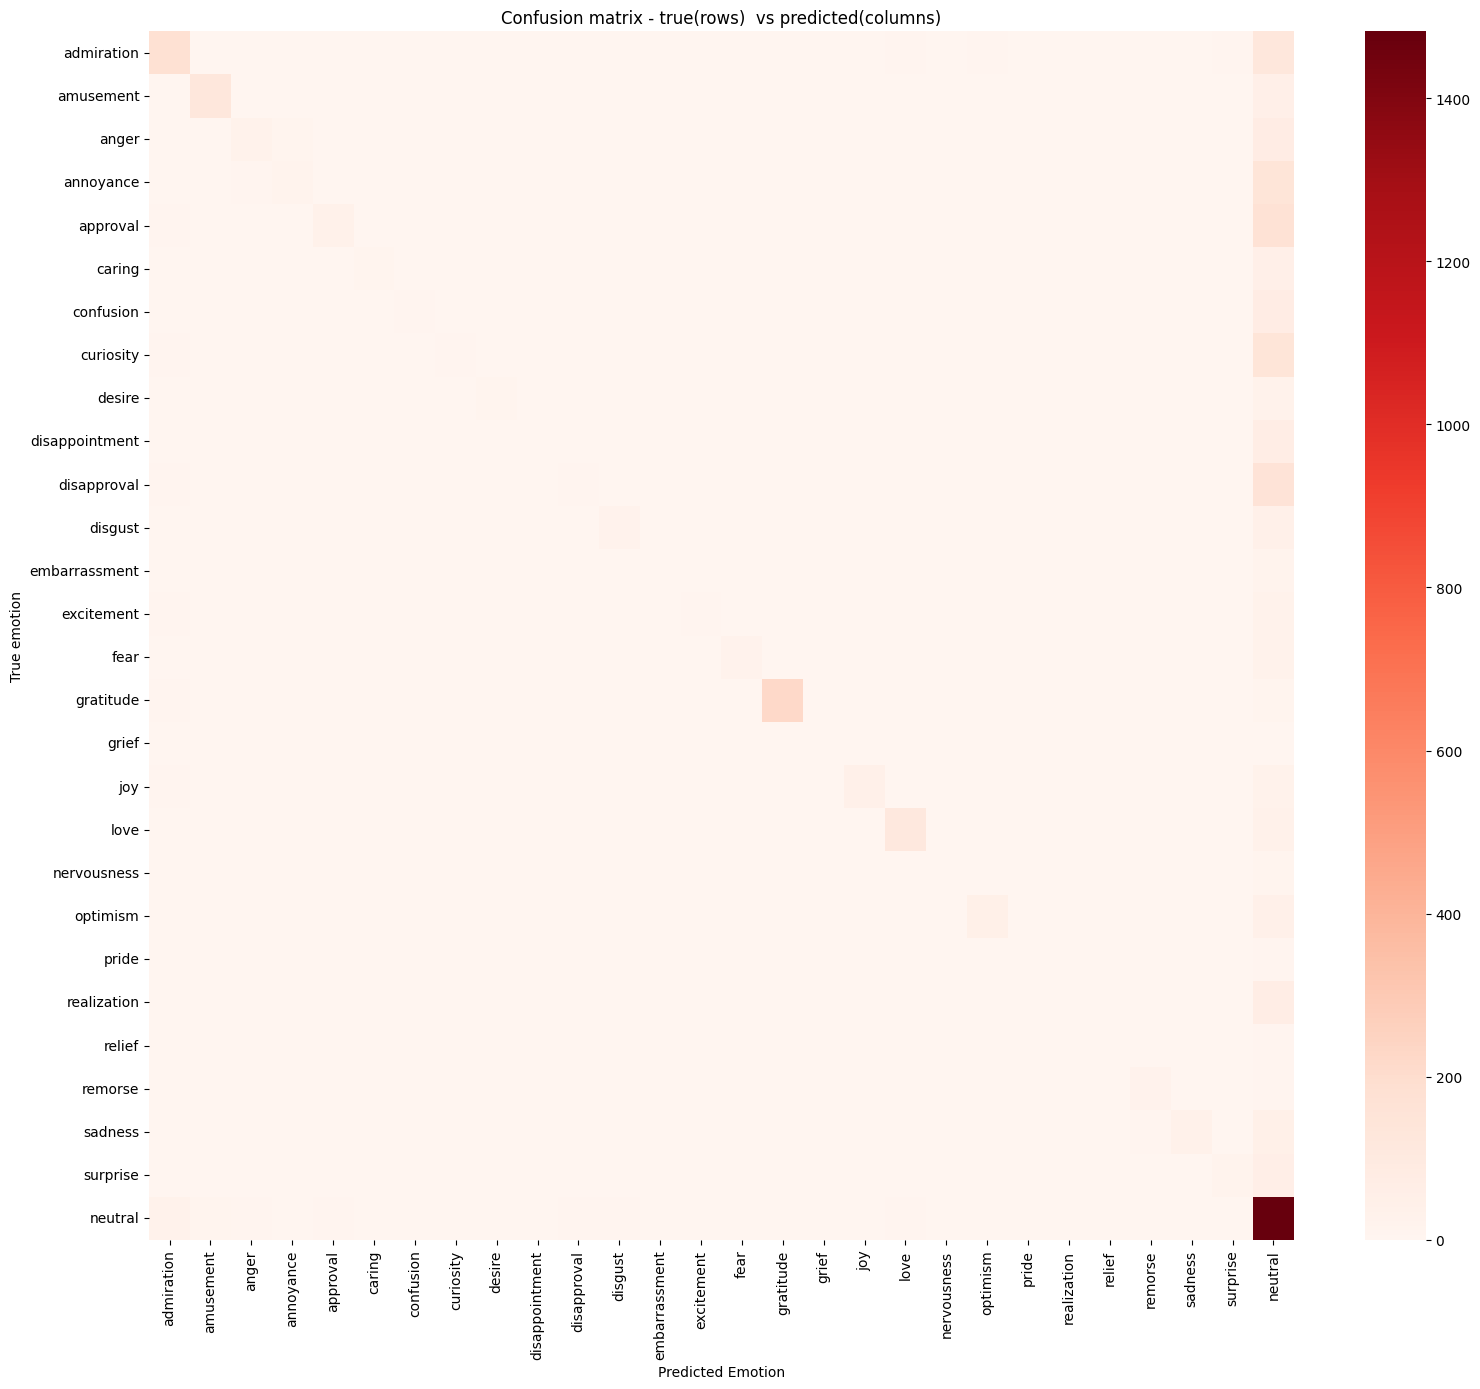

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns

cm = confusion_matrix(Y_test, Y_pred)

print(f"Matrix shape :{cm.shape}")

plt.figure(figsize=(16,14))

sns.heatmap(
    cm,
    annot=False,
    cmap='Reds',
    xticklabels=label_names,
    yticklabels=label_names   
)

plt.title('Confusion matrix - true(rows)  vs predicted(columns)')

plt.xlabel('Predicted Emotion')
plt.ylabel('True emotion')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# every off-diagonal confusion and their rank

confusion_pairs=[]
for i in range (len(label_names)):
    for j in range (len(label_names)):
        if i!=j and cm[i][j]>0:
            confusion_pairs.append((
                label_names[i],
                label_names[j],
                cm[i][j],
            ))

confusion_pairs.sort(key=lambda x: x[2] , reverse=True)

print("Top 15 biggest emotion confusions (True -> Predicted):")

for true_em , pred_em , count in confusion_pairs[:15]:
    print(f" {true_em}--> {pred_em}: {count} times ")
            



Top 15 biggest emotion confusions (True -> Predicted):
 approval--> neutral: 173 times 
 disapproval--> neutral: 157 times 
 curiosity--> neutral: 149 times 
 annoyance--> neutral: 148 times 
 admiration--> neutral: 127 times 
 confusion--> neutral: 80 times 
 anger--> neutral: 77 times 
 realization--> neutral: 71 times 
 disappointment--> neutral: 70 times 
 surprise--> neutral: 59 times 
 amusement--> neutral: 54 times 
 caring--> neutral: 54 times 
 sadness--> neutral: 52 times 
 disgust--> neutral: 44 times 
 optimism--> neutral: 43 times 
